In [28]:
library(dplyr)
library(tidyr)
library(hms)
library(lubridate)
library(ggplot2)
library(purrr)
library(tidyverse)
library(cowplot)
library(readr)
library(patchwork)

In [29]:
od_tp <-read_tsv("od_tp_comparison.tsv")

od_long <- od_tp %>%
  
  # remove empty rows
  filter(!is.na(Time)) %>%
  
  # pivot replicate columns
  pivot_longer(
    cols = c(R1, R2, R3),
    names_to = "Replicate",
    values_to = "OD"
  ) %>%
  
  # clean replicate labels
  mutate(
    Replicate = gsub("R", "", Replicate),
    Replicate = as.integer(Replicate)
  ) %>%
  
  # ensure clean types
  mutate(
    Strains = as.character(Strains),
    Conditions = as.character(Conditions),
    Equipment = as.character(Equipment)
  ) %>%
  
  rename(
    Strain = Strains,
    Carbon = Conditions,
    Instrument = Equipment
  ) %>%
  
  select(Time, Strain, Carbon, Instrument, Replicate, OD)


head(od_long)

Rows: 64 Columns: 7
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr (3): Strains, Conditions, Equipment
dbl (4): Time, R1, R2, R3

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


Time,Strain,Carbon,Instrument,Replicate,OD
<dbl>,<chr>,<chr>,<chr>,<int>,<dbl>
0,ATCC_29213,BHI,Cuvette,1,0.04
0,ATCC_29213,BHI,Cuvette,2,0.05
0,ATCC_29213,BHI,Cuvette,3,0.04
0,ATCC_29213,TSB,Cuvette,1,0.03
0,ATCC_29213,TSB,Cuvette,2,0.04
0,ATCC_29213,TSB,Cuvette,3,0.03


In [30]:
tail(od_long)

Time,Strain,Carbon,Instrument,Replicate,OD
<dbl>,<chr>,<chr>,<chr>,<int>,<dbl>
24,Controle,M9_GLU,VictorX3,1,0.066
24,Controle,M9_GLU,VictorX3,2,0.066
24,Controle,M9_GLU,VictorX3,3,0.066
24,Controle,M9VIT_GLU,VictorX3,1,0.072
24,Controle,M9VIT_GLU,VictorX3,2,0.072
24,Controle,M9VIT_GLU,VictorX3,3,0.072


In [31]:
# Compute deltaOD from time points 0 and 24h
od_delta <- od_long %>%
  
  filter(Time %in% c(0, 24)) %>%
  
  pivot_wider(
    id_cols = c(Strain, Carbon, Instrument, Replicate),
    names_from = Time,
    values_from = OD,
    names_prefix = "t"
  ) %>%
  
  mutate(
    delta_OD = t24 - t0,
    fold_change = t24 / t0
  ) %>%
  
  filter(!is.na(delta_OD))

head(od_delta)

Strain,Carbon,Instrument,Replicate,t0,t24,delta_OD,fold_change
<chr>,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>
ATCC_29213,BHI,Cuvette,1,0.04,2.04,2.00,51.0
ATCC_29213,BHI,Cuvette,2,0.05,1.84,1.79,36.8
ATCC_29213,BHI,Cuvette,3,0.04,1.98,1.94,49.5
ATCC_29213,TSB,Cuvette,1,0.03,3.66,3.63,122.0
ATCC_29213,TSB,Cuvette,2,0.04,3.78,3.74,94.5
ATCC_29213,TSB,Cuvette,3,0.03,3.54,3.51,118.0


In [32]:
# Compute main stats across replicates
summary_delta <- od_delta %>%
  group_by(Strain, Carbon, Instrument) %>%
  summarise(
    mean_delta = mean(delta_OD),
    sd_delta = sd(delta_OD),
    sem_delta = sd(delta_OD) / sqrt(n()),
    mean_fc = mean(fold_change),
    n = n(),
    .groups = "drop"
  )
head(summary_delta)

Strain,Carbon,Instrument,mean_delta,sd_delta,sem_delta,mean_fc,n
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<int>
ATCC_29213,BHI,Cuvette,1.9100000,0.10816654,0.06244998,45.766667,3
ATCC_29213,BHI,Synergy_LID,0.8223333,0.06069871,0.03504442,6.975192,3
ATCC_29213,BHI,Synergy_noLID,0.5716667,0.04895236,0.02826266,5.153839,3
ATCC_29213,BHI,VictorX3,0.2966667,0.03666515,0.02116864,2.344604,3
ATCC_29213,M9VIT_GLU,Cuvette,3.7100000,0.03000000,0.01732051,93.750000,3
ATCC_29213,M9VIT_GLU,Synergy_LID,1.6743333,0.02193931,0.01266667,15.827366,3


In [33]:
sort(unique(summary_delta$Instrument))

[1] "Cuvette"       "Synergy_LID"   "Synergy_noLID" "VictorX3"

In [34]:
summary_delta <- summary_delta %>%
  filter(Strain == "ATCC_29213")

od_delta <- od_delta %>%
  filter(Strain == "ATCC_29213")

In [35]:
summary_delta <- summary_delta %>%
  mutate(Carbon = factor(Carbon,
                         levels = c("TSB", "BHI", "M9VIT_GLU", "M9_GLU")))

od_delta <- od_delta %>%
  mutate(Carbon = factor(Carbon,
                         levels = c("TSB", "BHI", "M9VIT_GLU", "M9_GLU")))

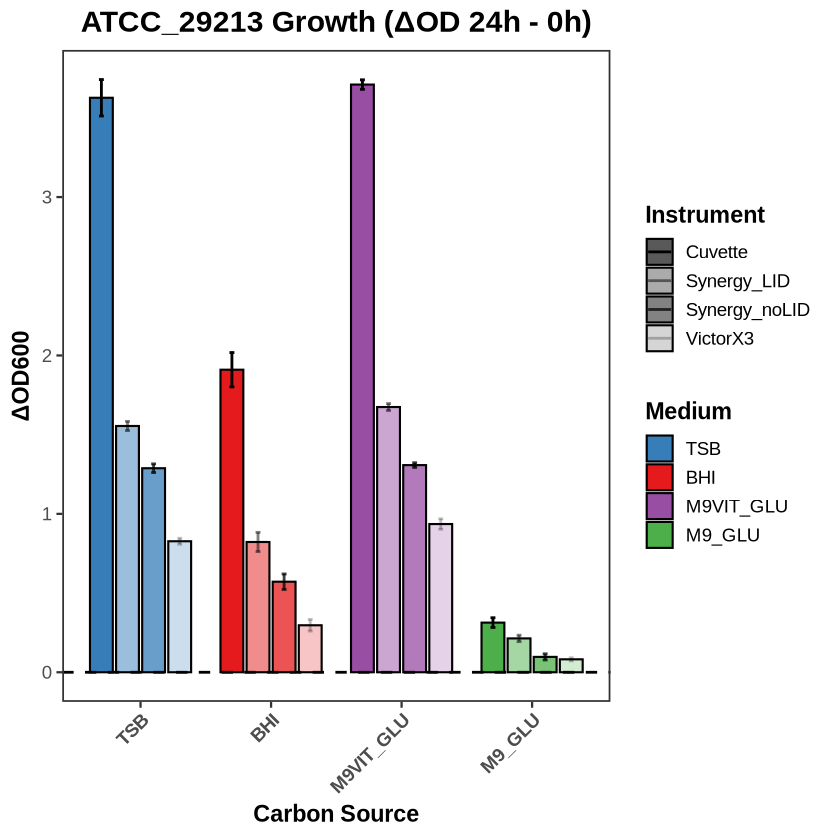

In [39]:
library(ggplot2)

plot_delta <- ggplot(summary_delta,
                     aes(x = Carbon, y = mean_delta,
                         fill = Carbon,
                         alpha = Instrument)) +
  
  geom_col(
    position = position_dodge(width = 0.8),
    color = "black",
    linewidth = 0.6,
    width = 0.7
  ) +
  
  geom_errorbar(
    aes(
      ymin = mean_delta - sd_delta,
      ymax = mean_delta + sd_delta
    ),
    position = position_dodge(width = 0.8),
    width = 0.15,
    linewidth = 0.8
  ) +
  
  # geom_jitter(
  #   data = od_delta,
  #   aes(x = Carbon, y = delta_OD),
  #   position = position_jitterdodge(
  #     jitter.width = 0.1,
  #     dodge.width = 0.8
  #   ),
  #   size = 2.5,
  #   shape = 21,
  #   fill = "white",
  #   color = "black",
  #   inherit.aes = FALSE
  # ) +
  
  scale_fill_manual(
    values = c(
      "BHI" = "#E41A1C",
      "TSB" = "#377EB8",
      "M9_GLU" = "#4DAF4A",
      "M9VIT_GLU" = "#984EA3"
    )
  ) +
  
  scale_alpha_manual(
    values = c(
      "Cuvette" = 1,
      "Synergy_noLID" = 0.75,
      "Synergy_LID" = 0.5,
      "VictorX3" = 0.25
    )
  ) +
  
  geom_hline(yintercept = 0, linetype = "dashed", linewidth = 0.8) +
  
  labs(
    title = "ATCC_29213 Growth (ΔOD 24h - 0h)",
    x = "Carbon Source",
    y = "ΔOD600",
    fill = "Medium",
    alpha = "Instrument"
  ) +
  
  theme_bw(base_size = 14) +
  
  theme(
    plot.title = element_text(size = 18, face = "bold", hjust = 0.5),
    axis.text.x = element_text(angle = 45, hjust = 1, face = "bold"),
    axis.title = element_text(face = "bold"),
    legend.title = element_text(face = "bold"),
    panel.grid = element_blank(),
    panel.border = element_rect(linewidth = 1)
  )

plot_delta


Attaching package: ‘scales’


The following object is masked from ‘package:readr’:

    col_factor


The following object is masked from ‘package:purrr’:

    discard




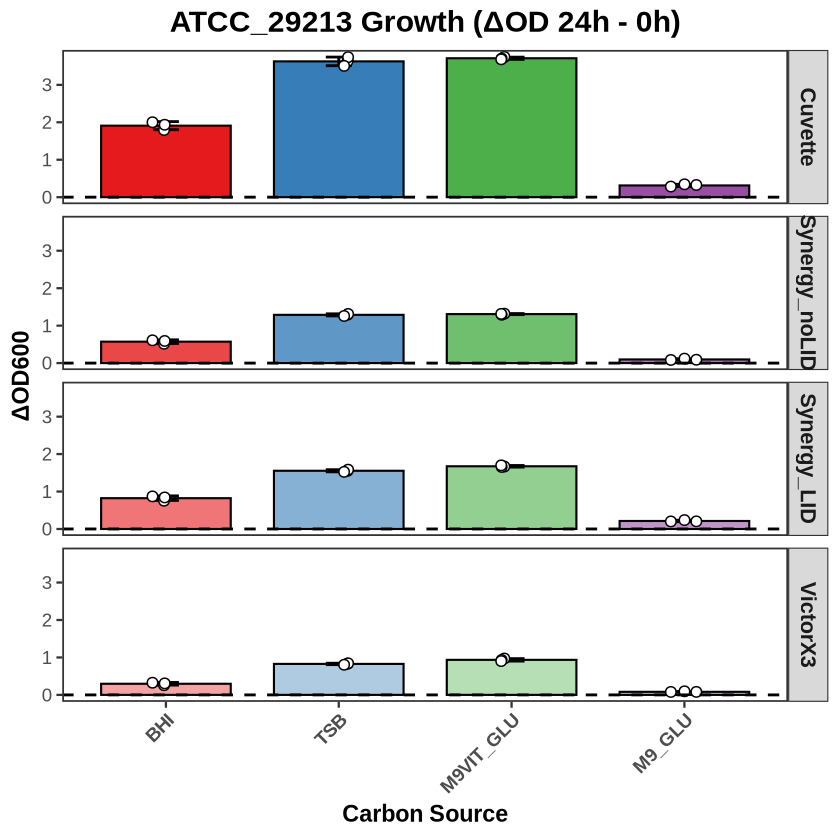

In [40]:
library(dplyr)
library(ggplot2)
library(scales)

# ----------------------------
# 1. Ensure correct ordering
# ----------------------------
summary_delta <- summary_delta %>%
  filter(Strain == "ATCC_29213") %>%
  mutate(
    Carbon = factor(Carbon,
                    levels = c("BHI", "TSB", "M9VIT_GLU", "M9_GLU")),
    Instrument = factor(Instrument,
                        levels = c("Cuvette", "Synergy_noLID", "Synergy_LID", "VictorX3"))
  )

od_delta <- od_delta %>%
  filter(Strain == "ATCC_29213") %>%
  mutate(
    Carbon = factor(Carbon,
                    levels = c("BHI", "TSB", "M9VIT_GLU", "M9_GLU")),
    Instrument = factor(Instrument,
                        levels = c("Cuvette", "Synergy_noLID", "Synergy_LID", "VictorX3"))
  )

# ----------------------------
# 2. Define base colors (Carbon)
# ----------------------------
base_cols <- c(
  "BHI" = "#E41A1C",
  "TSB" = "#377EB8",
  "M9VIT_GLU" = "#4DAF4A",
  "M9_GLU" = "#984EA3"
)

# ----------------------------
# 3. Instrument shading (lightness adjustment)
# ----------------------------
shade_factor <- c(
  "Cuvette" = 0.00,
  "Synergy_noLID" = 0.20,
  "Synergy_LID" = 0.40,
  "VictorX3" = 0.60
)

# attach shaded colors
summary_delta <- summary_delta %>%
  mutate(
    fill_col = mapply(
      function(carbon, inst) {
        col <- base_cols[[carbon]]
        alpha(col, 1 - shade_factor[[inst]])
      },
      Carbon,
      Instrument
    )
  )

od_delta <- od_delta %>%
  mutate(
    fill_col = mapply(
      function(carbon, inst) {
        col <- base_cols[[carbon]]
        alpha(col, 1 - shade_factor[[inst]])
      },
      Carbon,
      Instrument
    )
  )

# ----------------------------
# 4. Plot
# ----------------------------
plot_delta <- ggplot(summary_delta,
                     aes(x = Carbon, y = mean_delta)) +

  geom_col(
    aes(fill = fill_col),
    color = "black",
    linewidth = 0.6,
    width = 0.75
  ) +

  geom_errorbar(
    aes(
      ymin = mean_delta - sd_delta,
      ymax = mean_delta + sd_delta,
      group = Instrument
    ),
    width = 0.15,
    linewidth = 0.8
  ) +

  geom_jitter(
    data = od_delta,
    aes(x = Carbon, y = delta_OD),
    width = 0.08,
    size = 2.5,
    shape = 21,
    fill = "white",
    color = "black",
    inherit.aes = FALSE
  ) +

  facet_grid(Instrument ~ .) +

  scale_fill_identity() +

  geom_hline(yintercept = 0, linetype = "dashed", linewidth = 0.8) +

  labs(
    title = "ATCC_29213 Growth (ΔOD 24h - 0h)",
    x = "Carbon Source",
    y = "ΔOD600"
  ) +

  theme_bw(base_size = 14) +

  theme(
    plot.title = element_text(size = 18, face = "bold", hjust = 0.5),
    strip.text = element_text(size = 13, face = "bold"),
    axis.text.x = element_text(angle = 45, hjust = 1, face = "bold"),
    axis.title = element_text(face = "bold"),
    panel.grid = element_blank(),
    panel.border = element_rect(linewidth = 1)
  )

plot_delta

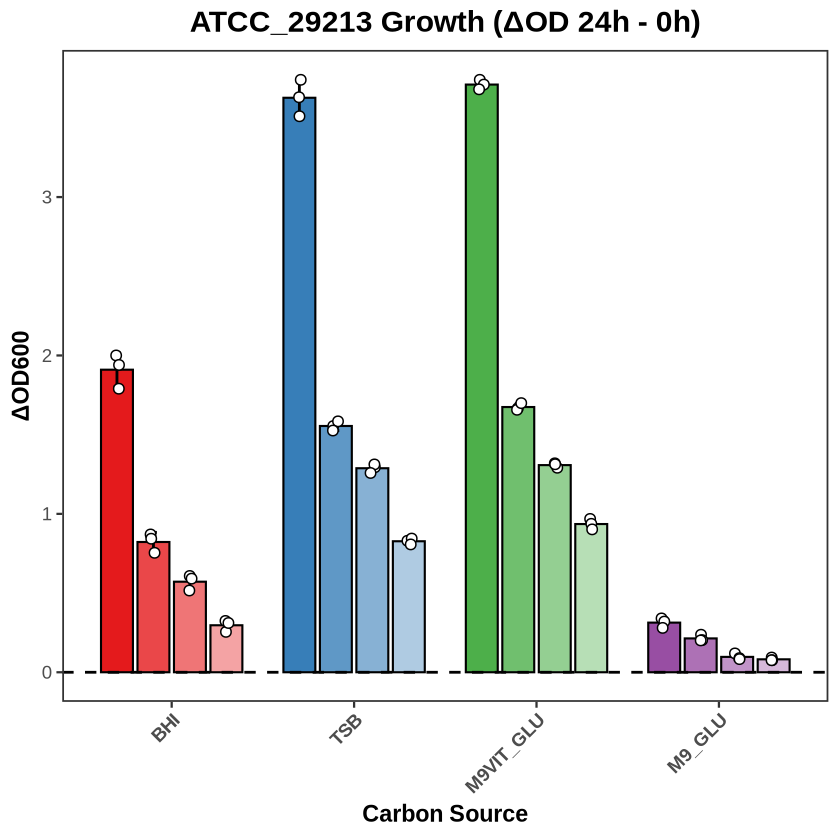

In [45]:
library(dplyr)
library(ggplot2)
library(scales)

# ----------------------------
# 1. Keep only ATCC strain + ordering
# ----------------------------
summary_delta <- summary_delta %>%
  filter(Strain == "ATCC_29213") %>%
  mutate(
    Carbon = factor(Carbon,
                    levels = c("BHI", "TSB", "M9VIT_GLU", "M9_GLU")),
    Instrument = factor(Instrument,
                        levels = c("Cuvette", "Synergy_LID", "Synergy_noLID", "VictorX3"))
  )

od_delta <- od_delta %>%
  filter(Strain == "ATCC_29213") %>%
  mutate(
    Carbon = factor(Carbon,
                    levels = c("BHI", "TSB", "M9VIT_GLU", "M9_GLU")),
    Instrument = factor(Instrument,
                        levels = c("Cuvette", "Synergy_LID", "Synergy_noLID", "VictorX3"))
  )

# ----------------------------
# 2. Base carbon colors
# ----------------------------
base_cols <- c(
  "BHI" = "#E41A1C",
  "TSB" = "#377EB8",
  "M9VIT_GLU" = "#4DAF4A",
  "M9_GLU" = "#984EA3"
)

# ----------------------------
# 3. Instrument shading
# ----------------------------
shade_factor <- c(
  "Cuvette" = 0.00,
  "Synergy_LID" = 0.20,
  "Synergy_noLID" = 0.40,
  "VictorX3" = 0.60
)

summary_delta <- summary_delta %>%
  mutate(
    fill_col = mapply(
      function(carbon, inst) {
        alpha(base_cols[[carbon]], 1 - shade_factor[[inst]])
      },
      Carbon,
      Instrument
    )
  )

od_delta <- od_delta %>%
  mutate(
    fill_col = mapply(
      function(carbon, inst) {
        alpha(base_cols[[carbon]], 1 - shade_factor[[inst]])
      },
      Carbon,
      Instrument
    )
  )

# ----------------------------
# 4. PLOT (grouped bars)
# ----------------------------
plot_delta <- ggplot(summary_delta,
                     aes(x = Carbon, y = mean_delta, group = Instrument)) +

  geom_col(
    aes(fill = fill_col),
    position = position_dodge(width = 0.8),
    color = "black",
    linewidth = 0.6,
    width = 0.7
  ) +

  geom_errorbar(
    aes(
      ymin = mean_delta - sd_delta,
      ymax = mean_delta + sd_delta
    ),
    position = position_dodge(width = 0.8),
    width = 0.15,
    linewidth = 0.8
  ) +

  geom_jitter(
    data = od_delta,
    aes(x = Carbon, y = delta_OD, group = Instrument),
    position = position_jitterdodge(
      dodge.width = 0.8,
      jitter.width = 0.1
    ),
    size = 2.5,
    shape = 21,
    fill = "white",
    color = "black",
    inherit.aes = FALSE
  ) +

  scale_fill_identity() +

  geom_hline(yintercept = 0, linetype = "dashed", linewidth = 0.8) +

  labs(
    title = "ATCC_29213 Growth (ΔOD 24h - 0h)",
    x = "Carbon Source",
    y = "ΔOD600"
  ) +

  theme_bw(base_size = 14) +

  theme(
    plot.title = element_text(size = 18, face = "bold", hjust = 0.5),
    axis.text.x = element_text(angle = 45, hjust = 1, face = "bold"),
    axis.title = element_text(face = "bold"),
    panel.grid = element_blank(),
    panel.border = element_rect(linewidth = 1)
  )

plot_delta

In [46]:
ggsave("od_comparison_m9_vitor.png")

Saving 6.67 x 6.67 in image


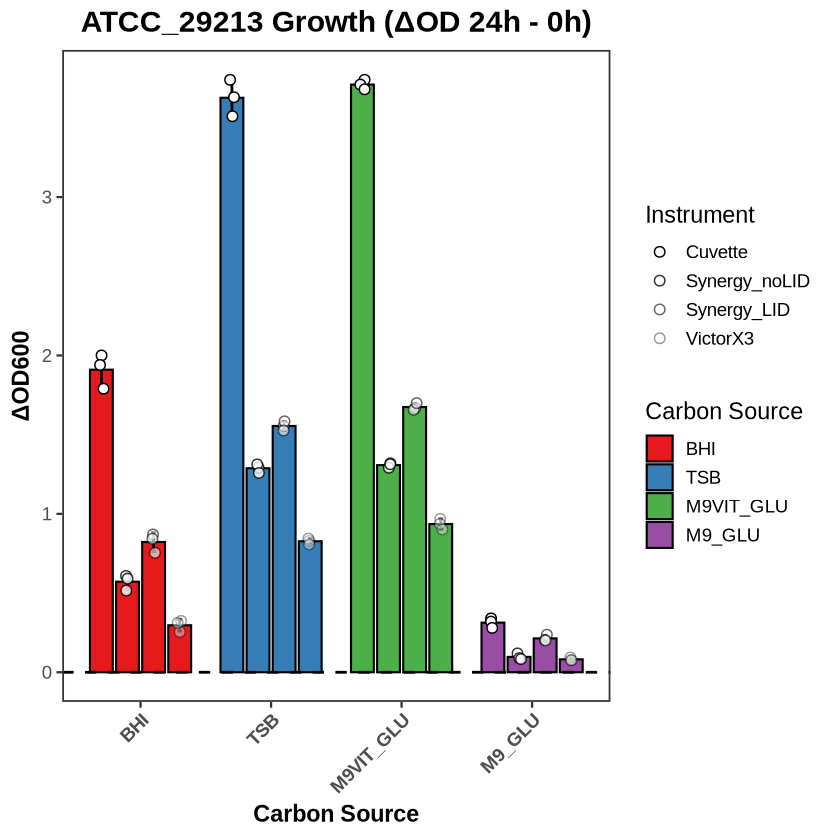

In [43]:
library(dplyr)
library(ggplot2)

summary_delta <- summary_delta %>%
  filter(Strain == "ATCC_29213") %>%
  mutate(
    Carbon = factor(Carbon,
                    levels = c("BHI", "TSB", "M9VIT_GLU", "M9_GLU")),
    Instrument = factor(Instrument,
                        levels = c("Cuvette", "Synergy_noLID", "Synergy_LID", "VictorX3"))
  )

od_delta <- od_delta %>%
  filter(Strain == "ATCC_29213") %>%
  mutate(
    Carbon = factor(Carbon,
                    levels = c("BHI", "TSB", "M9VIT_GLU", "M9_GLU")),
    Instrument = factor(Instrument,
                        levels = c("Cuvette", "Synergy_noLID", "Synergy_LID", "VictorX3"))
  )

# Carbon colors (legend kept)
base_cols <- c(
  "BHI" = "#E41A1C",
  "TSB" = "#377EB8",
  "M9VIT_GLU" = "#4DAF4A",
  "M9_GLU" = "#984EA3"
)

# Instrument shading via alpha (legend kept separately)
alpha_levels <- c(
  "Cuvette" = 1.0,
  "Synergy_noLID" = 0.8,
  "Synergy_LID" = 0.6,
  "VictorX3" = 0.4
)

plot_delta <- ggplot(summary_delta,
                     aes(x = Carbon,
                         y = mean_delta,
                         fill = Carbon,
                         group = Instrument)) +

  geom_col(
    position = position_dodge(width = 0.8),
    color = "black",
    linewidth = 0.6,
    width = 0.7
  ) +

  geom_errorbar(
    aes(
      ymin = mean_delta - sd_delta,
      ymax = mean_delta + sd_delta
    ),
    position = position_dodge(width = 0.8),
    width = 0.15,
    linewidth = 0.8
  ) +

  geom_jitter(
    data = od_delta,
    aes(x = Carbon,
        y = delta_OD,
        alpha = Instrument),
    position = position_jitterdodge(
      dodge.width = 0.8,
      jitter.width = 0.1
    ),
    size = 2.5,
    shape = 21,
    fill = "white",
    color = "black",
    inherit.aes = FALSE
  ) +

  scale_fill_manual(values = base_cols) +
  scale_alpha_manual(values = alpha_levels) +

  geom_hline(yintercept = 0, linetype = "dashed", linewidth = 0.8) +

  labs(
    title = "ATCC_29213 Growth (ΔOD 24h - 0h)",
    x = "Carbon Source",
    y = "ΔOD600",
    fill = "Carbon Source",
    alpha = "Instrument"
  ) +

  theme_bw(base_size = 14) +

  theme(
    plot.title = element_text(size = 18, face = "bold", hjust = 0.5),
    axis.text.x = element_text(angle = 45, hjust = 1, face = "bold"),
    axis.title = element_text(face = "bold"),
    panel.grid = element_blank(),
    panel.border = element_rect(linewidth = 1)
  )

plot_delta